In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from lstm import LoanDefaultModel, LoanDefaultDataset
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from tqdm import tqdm

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

/opt/anaconda3/envs/creditrisk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading

In [2]:
DATA_PATH = "../data/credit_risk_dataset_5k_processed[2006,2018].csv"
df = pd.read_csv(DATA_PATH, parse_dates=["time_series"])
print(f"\nTotal rows: {len(df):,}")
print(f"Number of Customers: {df['id'].nunique():,}")
df.head()


Total rows: 34,984
Number of Customers: 3,889


,time_series,id,Business Relation Client,Cash Flow Ratio,Covenants Breach last 12 Month,DPD 10 Days Flag,EBITDA,Equity Ratio,Financial DSCR,Financial financing cost,...,Population Growth (%),Total Assets,Invested Capital,ROE,Syndicated Flag,Object Value Change,Object Value Change 3 Year,Default Flag,CMS Country Longitude,CMS Country Latitude
0,2015-06-01,10000,1.0,0.59193,0.0,0.0,177053.58446,0.10028,2.09076,0.02052,...,0.012,5.220292e+06,4.056298e+06,0.47839,1,0.020877,0.020877,0.0,8.227512,46.818188
1,2016-06-01,10000,1.0,0.70786,0.0,0.0,178991.56297,0.09568,2.20574,0.02196,...,0.011,5.182735e+06,5.137940e+06,0.49693,1,-0.003958,0.067600,0.0,8.227512,46.818188
2,2017-06-01,10000,1.0,0.82379,0.0,0.0,191490.30717,0.09359,2.08977,0.02099,...,0.011,5.480834e+06,4.301013e+06,0.47833,1,-0.003958,0.000710,0.0,8.227512,46.818188
3,2018-06-01,10000,1.0,0.93972,0.0,0.0,178374.42878,0.09482,2.04037,0.02095,...,0.009,5.259656e+06,5.248983e+06,0.49897,1,-0.003958,0.058440,0.0,8.227512,46.818188
4,2006-06-01,10001,3.0,0.50054,0.0,0.0,842600.26441,0.12990,0.98453,0.29209,...,0.003,1.518746e+07,1.126279e+07,0.25669,0,-0.016524,-0.016524,0.0,9.501785,56.263920


In [3]:
exclude_cols = ['time_series', 'id', 'Default Flag']
feature_cols = [col for col in df.columns if col not in exclude_cols]
print(f"Number of features: {len(feature_cols)}")

Number of features: 33


In [4]:
scaler = StandardScaler()
df_processed = df.copy()
df_processed[feature_cols] = scaler.fit_transform(df_processed[feature_cols])

## 2. Padding

In [5]:
sequences = []
targets = []
customer_ids = []

for id in df_processed['id'].unique():
    loan_data = df_processed[df_processed["id"] == id].sort_values('time_series')
    X_seq = loan_data[feature_cols].values
    y_final = loan_data['Default Flag'].iloc[-1]

    sequences.append(X_seq)
    targets.append(y_final)
    customer_ids.append(id)

print(f"Total loans: {len(sequences)}")

n_loans = len(sequences)
max_len = max(len(seq) for seq in sequences)
n_features = len(feature_cols)

X_padded = np.zeros((n_loans, max_len, n_features))
y_padded = np.zeros((n_loans, 1))

for i, (seq, target) in enumerate(zip(sequences, targets)):
    seq_len = len(seq)
    X_padded[i, -seq_len:, :] = seq
    y_padded[i, 0] = target

print(f"Final shape: X={X_padded.shape}, y={y_padded.shape}")
n_class_0 = (y_padded == 0).sum()
n_class_1 = (y_padded == 1).sum()

print(f"\nClass distribution:")
print(f"  Class 0 (no default): {n_class_0} ({n_class_0/n_loans*100:.2f}%)")
print(f"  Class 1 (default):    {n_class_1} ({n_class_1/n_loans*100:.2f}%)")

Total loans: 3889
Final shape: X=(3889, 13, 33), y=(3889, 1)

Class distribution:
  Class 0 (no default): 3422 (87.99%)
  Class 1 (default):    467 (12.01%)


## 3. Train_Test Split

In [6]:
# np.savez_compressed(
#     "../data/credit_risk_dataset_5k_padded.npz",
#     X_padded=X_padded,
#     y_padded=y_padded,
#     customer_ids=np.array(customer_ids),
#     feature_cols=np.array(feature_cols)
# )
# print("Saved to loan_sequences_padded.npz")

data = np.load("../data/credit_risk_dataset_5k_padded.npz", allow_pickle=True)
X_padded      = data["X_padded"]
y_padded      = data["y_padded"]
customer_ids  = data["customer_ids"]
feature_cols  = data["feature_cols"]

In [7]:
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test, id_temp, id_test= train_test_split(
    X_padded, y_padded, customer_ids,
    test_size=0.15,
    random_state=1024,
    stratify=y_padded
)
X_train, X_val, y_train, y_val, id_train, id_val = train_test_split(
    X_temp, y_temp, id_temp,
    test_size=0.18,
    random_state=1024,
    stratify=y_temp
)

print(f"Train: {len(X_train):,} loans (Class 1: {(y_train==1).sum()})")
print(f"Val:   {len(X_val):,} loans (Class 1: {(y_val==1).sum()})")
print(f"Test:  {len(X_test):,} loans (Class 1: {(y_test==1).sum()})")

Train: 2,710 loans (Class 1: 326)
Val:   595 loans (Class 1: 71)
Test:  584 loans (Class 1: 70)


## 4. Model Training

In [8]:
model = LoanDefaultModel(input_size=33, hidden_size=32)

batch_size = 128

train_dataset = LoanDefaultDataset(X_train, y_train)
val_dataset = LoanDefaultDataset(X_val, y_val)
test_dataset = LoanDefaultDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


### Loss Function

In [9]:
n_class_0 = (y_train == 0).sum()
n_class_1 = (y_train == 1).sum()
pos_weight = torch.tensor([n_class_0/n_class_1])

print(f"Class imbalance ratio: {n_class_0/n_class_1:.1f}:1")
print(f"Positive class weight: {pos_weight.item():.2f}")

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

Class imbalance ratio: 7.3:1
Positive class weight: 7.31


### Optimizer & Scheduler

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10, verbose=True
)

history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
    'val_recall': [],
    'val_precision': []
}

best_val_f1 = 0.0

### Training

In [11]:
n_class_0 = (y_train == 0).sum()
n_class_1 = (y_train == 1).sum()
pos_weight = torch.tensor([n_class_0 / n_class_1])

print("="*70)
print("TRAINING SETUP")
print("="*70)
print(f"Class imbalance ratio: {n_class_0/n_class_1:.1f}:1")
print(f"Positive class weight: {pos_weight.item():.2f}")
print("="*70 + "\n")

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, verbose=True
)

history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
    'val_recall': [],
    'val_precision': []
}

best_val_f1 = 0.0

epochs = 100
for epoch in tqdm(range(epochs), desc="Training Progress"):
    
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        outputs = model(X_batch)  # (batch, 1)
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
    
    # Validation
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_probs = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            
            # Loss
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            
            # Predictions
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            
            # Collect predictions
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())
    
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    val_acc = accuracy_score(all_targets, all_preds)
    val_precision = precision_score(all_targets, all_preds, zero_division=0)
    val_recall = recall_score(all_targets, all_preds, zero_division=0)
    val_f1 = f1_score(all_targets, all_preds, zero_division=0)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    history['val_f1'].append(val_f1)
    
    # Update learning rate
    scheduler.step(avg_val_loss)
    
    # SAVE BEST MODEL
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model.pth')
    
    if (epoch + 1) % 10 == 0:
        cm = confusion_matrix(all_targets, all_preds)
        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
        
        print(f"\nEpoch {epoch+1:3d}/{epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"  Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        print(f"  Precision: {val_precision:.4f} | Recall: {val_recall:.4f}")
        print(f"  Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

TRAINING SETUP
Class imbalance ratio: 7.3:1
Positive class weight: 7.31



Training Progress:  11%|█         | 11/100 [00:01<00:12,  7.05it/s]


Epoch  10/100
  Train Loss: 1.1132 | Val Loss: 1.1230
  Val Acc: 0.3513 | F1: 0.2662
  Precision: 0.1538 | Recall: 0.9859
  Confusion Matrix: TN=139, FP=385, FN=1, TP=70


Training Progress:  21%|██        | 21/100 [00:03<00:10,  7.18it/s]


Epoch  20/100
  Train Loss: 0.9134 | Val Loss: 0.9222
  Val Acc: 0.5647 | F1: 0.3509
  Precision: 0.2134 | Recall: 0.9859
  Confusion Matrix: TN=266, FP=258, FN=1, TP=70


...


Epoch  90/100
  Train Loss: 0.1992 | Val Loss: 0.5654
  Val Acc: 0.9059 | F1: 0.6706
  Precision: 0.5758 | Recall: 0.8028
  Confusion Matrix: TN=482, FP=42, FN=14, TP=57


Training Progress:  97%|█████████▋| 97/100 [00:14<00:00,  6.37it/s]

Epoch 00096: reducing learning rate of group 0 to 6.2500e-06.


Training Progress: 100%|██████████| 100/100 [00:14<00:00,  6.87it/s]


Epoch 100/100
  Train Loss: 0.1984 | Val Loss: 0.5761
  Val Acc: 0.9076 | F1: 0.6746
  Precision: 0.5816 | Recall: 0.8028
  Confusion Matrix: TN=483, FP=41, FN=14, TP=57


## 5. Model Evaluation

In [12]:
device = 'cpu'
model_loaded = LoanDefaultModel(input_size=33, hidden_size=32)
model_loaded.load_state_dict(torch.load('best_model.pth'))
model_loaded.eval()
model_loaded = model_loaded.to(device)

all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model_loaded(X_batch)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())
all_preds = np.array(all_preds).flatten()
all_probs = np.array(all_probs).flatten()
all_targets = np.array(all_targets).flatten()

In [13]:
print("CLASSIFICATION METRICS")
print("="*70)

accuracy = accuracy_score(all_targets, all_preds)
precision = precision_score(all_targets, all_preds, zero_division=0)
recall = recall_score(all_targets, all_preds, zero_division=0)
f1 = f1_score(all_targets, all_preds, zero_division=0)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

roc_auc = roc_auc_score(all_targets, all_probs)
print(f"ROC-AUC:   {roc_auc:.4f}")

CLASSIFICATION METRICS

Accuracy:  0.9144
Precision: 0.6136
Recall:    0.7714
F1-Score:  0.6835
ROC-AUC:   0.9465


In [14]:
print("CLASSIFICATION REPORT")

target_names = ['No Default (0)', 'Default (1)']
print("\n" + classification_report(
    all_targets, 
    all_preds, 
    target_names=target_names,
    digits=4
))

CLASSIFICATION REPORT

                precision    recall  f1-score   support

No Default (0)     0.9677    0.9339    0.9505       514
   Default (1)     0.6136    0.7714    0.6835        70

      accuracy                         0.9144       584
     macro avg     0.7907    0.8526    0.8170       584
  weighted avg     0.9253    0.9144    0.9185       584



CONFUSION MATRIX


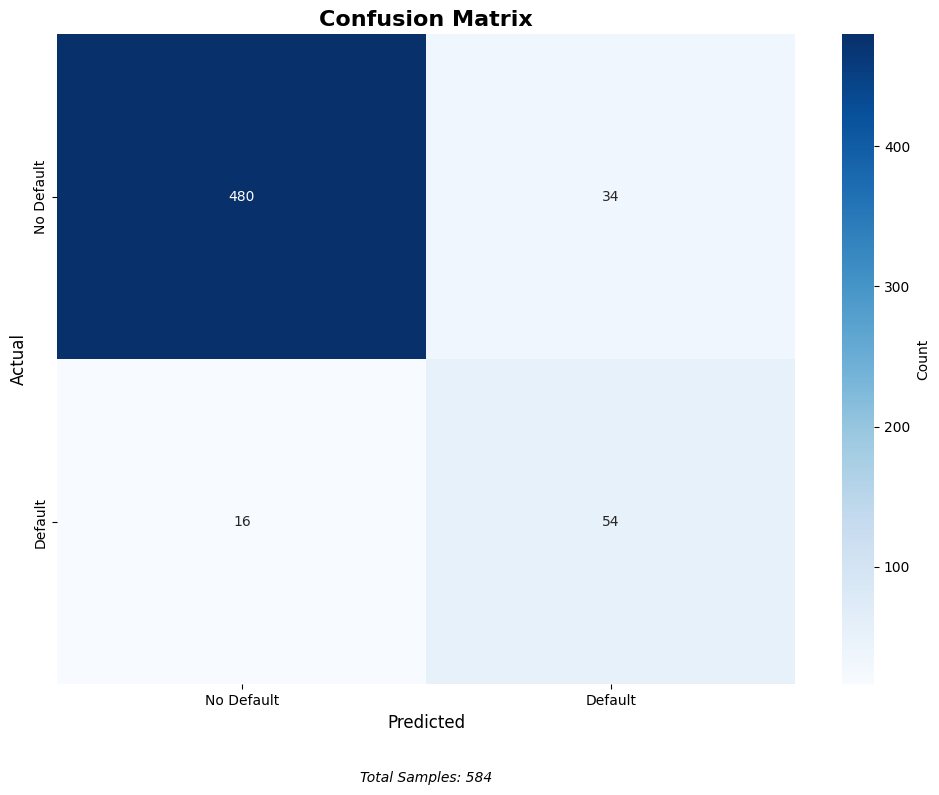

In [15]:
# Confusion Matrix
print("CONFUSION MATRIX")

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['No Default', 'Default'],
    yticklabels=['No Default', 'Default'],
    cbar_kws={'label': 'Count'}
)

plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

total = cm.sum()
plt.text(1, 2.3, f'Total Samples: {total}', 
         ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

### Save the model

In [16]:
# 1. Convert to TorchScript
scripted_model = torch.jit.script(model) 

# 2. Save
scripted_model.save("best_model_scripted.pt")